In [ ]:
!pip install catboost
!pip install xgboost
!pip install mord
import pandas as pd
import numpy as np
from tabulate import tabulate
from statsmodels.formula.api import ols
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,StandardScaler, LabelEncoder, OrdinalEncoder
from mord import LogisticIT
from xgboost import XGBClassifier
from xgboost import plot_importance
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
import joblib
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
from sklearn import set_config
set_config(transform_output='pandas')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for mord: filename=mord-0.7-py3-none-any.whl size=9885 sha256=81378ebc0c81c66276cbfc3c5463215cc6a4db52a57f9c429e4f61a55045fa34
  Stored in directory: /root/.cache/pip/wheels/80/3e/3b/13f1adf346cad0fec675db328e4b0d814795c6c8e2fb659122
Successfully built mord


# Exploracion previa del conjunto de datos

In [ ]:
df_final=pd.read_csv('df_final.csv',encoding='latin-1')
print(tabulate(df_final.head(), headers='keys', tablefmt='psql'))

+----+----------------------+--------+--------------------------+--------------------------------------------------------+-----------------------------------------------------------------------------------------------------+--------+--------------+----------------+----------------+--------------+------------------+-----------------+------------------+----------------+-------------------+------------------+--------------------+----------------+------------------+--------------------+--------+----------+---------+------------------------+-----------------------+-----------+
|    | Comunidad Autonoma   | Sexo   | Pais                     | Estudios                                               | Clase                                                                                               |   Edad |   Carne_frec |   Lacteos_frec |   Pescado_frec |   Fruta_frec |   Embutidos_frec |   Verduras_frec |   Refrescos_frec |   Alcohol_cant | Salud_Percibida   |   Cronicidad_bin |   Hipertens

In [ ]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21010 entries, 0 to 21009
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Comunidad Autonoma    21010 non-null  object 
 1   Sexo                  21010 non-null  object 
 2   Pais                  21010 non-null  object 
 3   Estudios              21010 non-null  object 
 4   Clase                 21010 non-null  object 
 5   Edad                  21010 non-null  int64  
 6   Carne_frec            20917 non-null  float64
 7   Lacteos_frec          20917 non-null  float64
 8   Pescado_frec          20909 non-null  float64
 9   Fruta_frec            20915 non-null  float64
 10  Embutidos_frec        20899 non-null  float64
 11  Verduras_frec         20911 non-null  float64
 12  Refrescos_frec        20893 non-null  float64
 13  Alcohol_cant          20959 non-null  float64
 14  Salud_Percibida       21010 non-null  object 
 15  Cronicidad_bin     

In [ ]:
print(tabulate(df_final.describe().round(2).T,headers='keys',tablefmt='psql'))

+---------------------+---------+--------+-------+-------+--------+--------+--------+--------+
|                     |   count |   mean |   std |   min |    25% |    50% |    75% |    max |
|---------------------+---------+--------+-------+-------+--------+--------+--------+--------|
| Edad                |   21010 |  54.49 | 19.14 |  15   |  40    |  55    |  69    | 103    |
| Carne_frec          |   20917 |   3.84 |  2.55 |   0   |   1.5  |   3    |   5    |  10    |
| Lacteos_frec        |   20917 |   7.9  |  3.24 |   0   |   5    |  10    |  10    |  10    |
| Pescado_frec        |   20909 |   2.15 |  1.59 |   0   |   1.5  |   1.5  |   3    |  10    |
| Fruta_frec          |   20915 |   7.01 |  3.53 |   0   |   3    |  10    |  10    |  10    |
| Embutidos_frec      |   20899 |   2.62 |  2.51 |   0   |   0.5  |   1.5  |   3    |  10    |
| Verduras_frec       |   20911 |   5.68 |  3.32 |   0   |   3    |   5    |  10    |  10    |
| Refrescos_frec      |   20893 |   1.13 |  2.1  |

In [ ]:
df_modelo= df_final.copy()

In [ ]:
# Manejo de NAS de las variables de interes

df_modelo= df_modelo.dropna(subset=['Hipertension_bin','Diabetes_bin','Colesterol_bin'])
df_modelo.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20472 entries, 0 to 21009
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Comunidad Autonoma    20472 non-null  object 
 1   Sexo                  20472 non-null  object 
 2   Pais                  20472 non-null  object 
 3   Estudios              20472 non-null  object 
 4   Clase                 20472 non-null  object 
 5   Edad                  20472 non-null  int64  
 6   Carne_frec            20392 non-null  float64
 7   Lacteos_frec          20390 non-null  float64
 8   Pescado_frec          20382 non-null  float64
 9   Fruta_frec            20391 non-null  float64
 10  Embutidos_frec        20375 non-null  float64
 11  Verduras_frec         20386 non-null  float64
 12  Refrescos_frec        20367 non-null  float64
 13  Alcohol_cant          20428 non-null  float64
 14  Salud_Percibida       20472 non-null  object 
 15  Cronicidad_bin        20

Predicción de la Hipertension

In [ ]:
# Separacion de variables categoricas y numericas. Se eliminan tambien las variables de Diabetes y Colesterol para evitar leakage
obj_cols = ['Diabetes_bin','Colesterol_bin', 'Hipertension_bin']
objetivo= 'Hipertension_bin'
df_cat= df_modelo.select_dtypes(include='object')
df_bin= df_modelo["Cronicidad_bin"].to_frame()
df_num= df_modelo.select_dtypes(include=np.number).drop(columns=['Diabetes_bin','Colesterol_bin', 'Hipertension_bin','Cronicidad_bin'], errors='ignore')

In [ ]:
print("\nColumnas categoricas:", df_cat.columns.to_list())
print("\nColumnas binarias:", df_bin.columns.to_list())
print("\nColumnas numericas:", df_num.columns.to_list())


Columnas categoricas: ['Comunidad Autonoma', 'Sexo', 'Pais', 'Estudios', 'Clase', 'Salud_Percibida', 'Actividad_física_cat', 'IMC_cat']

Columnas binarias: ['Cronicidad_bin']

Columnas numericas: ['Edad', 'Carne_frec', 'Lacteos_frec', 'Pescado_frec', 'Fruta_frec', 'Embutidos_frec', 'Verduras_frec', 'Refrescos_frec', 'Alcohol_cant', 'Comorbilidad_num', 'Peso', 'Altura', 'IMC', 'Sedentarismo%_horas']


# Modelado y evaluación

In [ ]:
X= df_modelo.drop(columns=['Diabetes_bin','Colesterol_bin','Hipertension_bin'])
y =df_modelo[objetivo]
X_train, X_test, y_train, y_test= train_test_split(X,y,test_size=0.25,random_state=42,stratify=y)

In [ ]:
# Transformadores por cada tipo de variable
# Decision de imputación https://machinelearningmastery.com/statistical-imputation-for-missing-values-in-machine-learning/

num_transformer= Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),('scaler', StandardScaler())])
bin_transformer= Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent'))])
cat_transformer= Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),('Ordinal', OrdinalEncoder())])

In [ ]:
preprocesado= ColumnTransformer([('num', num_transformer, df_num.columns.to_list()),
                ('bin', bin_transformer, df_bin.columns.to_list()),('cat', cat_transformer, df_cat.columns.to_list())])

In [ ]:
# Regresion logistica, random forest, Gradient Boostner
# ajuste de modelo: Balanceo de las clases con class_weight

pipelines= {"Regresion Logistica": Pipeline([("preprocesado", preprocesado), ("modelo", LogisticRegression(max_iter=2000, random_state=42))]),
            "Random Forest": Pipeline([("preprocesado", preprocesado), ("modelo", RandomForestClassifier(random_state=42,n_estimators=600,class_weight="balanced",n_jobs=-1))]),
            "Gradient Boosting": Pipeline([("preprocesado", preprocesado), ("modelo", GradientBoostingClassifier(learning_rate=0.05, random_state=42, n_estimators=600))])}

modelos= list(pipelines.values())

In [ ]:
resultados= {}
nom_modelos= ['Regresion Logistica', 'Random Forest', 'Gradient Boosting']

for nombre, pipeln in pipelines.items():
  print(f"Modelo: {nombre}")
  pipeln.fit(X_train, y_train)
  pred= pipeln.predict(X_test)

  acc= accuracy_score(y_test, pred)
  f1= f1_score(y_test, pred, average='macro', zero_division=0) # Manejo de undefined metric warning
  resultados[nombre]= f1
  print(f"Accuracy: {acc:.2f}")
  print(f"F1: {f1:.2f}")

  print(classification_report(y_test, pred, zero_division=0))
  print(confusion_matrix(y_test, pred))


Modelo: Regresion Logistica
Accuracy: 0.89
F1: 0.86
              precision    recall  f1-score   support

         0.0       0.90      0.94      0.92      3629
         1.0       0.85      0.75      0.79      1489

    accuracy                           0.89      5118
   macro avg       0.87      0.85      0.86      5118
weighted avg       0.89      0.89      0.89      5118

[[3428  201]
 [ 376 1113]]
Modelo: Random Forest
Accuracy: 0.88
F1: 0.86
              precision    recall  f1-score   support

         0.0       0.92      0.91      0.92      3629
         1.0       0.79      0.82      0.80      1489

    accuracy                           0.88      5118
   macro avg       0.86      0.86      0.86      5118
weighted avg       0.88      0.88      0.88      5118

[[3297  332]
 [ 269 1220]]
Modelo: Gradient Boosting
Accuracy: 0.89
F1: 0.86
              precision    recall  f1-score   support

         0.0       0.93      0.91      0.92      3629
         1.0       0.80      0.82  

In [ ]:
# Nombres para las columnas de la matriz

onehot_cols= preprocesado.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out()
col_names= np.concatenate([df_num.columns.to_list(),df_bin.columns.to_list(),onehot_cols])

# Mejoras de los modelos

Usando otros modelos

In [ ]:
# XGB

pipe_xgb= Pipeline([("preprocesado", preprocesado), ("modelo", XGBClassifier(objective="binary:logistic", n_estimators=600, learning_rate=0.05, max_depth=5, random_state=42))])

pipe_xgb.fit(X_train, y_train)
pred_xgb= pipe_xgb.predict(X_test)

acc_xgb= accuracy_score(y_test, pred_xgb)
f1_xgb= f1_score(y_test, pred_xgb, average='macro')
print(f"Accuracy: {acc_xgb:.2f}")
print(f"F1: {f1_xgb:.2f}")
print(classification_report(y_test, pred_xgb))
print(confusion_matrix(y_test, pred_xgb))

Accuracy: 0.88
F1: 0.86
              precision    recall  f1-score   support

         0.0       0.92      0.91      0.91      3629
         1.0       0.78      0.82      0.80      1489

    accuracy                           0.88      5118
   macro avg       0.85      0.86      0.86      5118
weighted avg       0.88      0.88      0.88      5118

[[3286  343]
 [ 268 1221]]


In [ ]:
# lightGBM

from lightgbm import LGBMClassifier

pipe_lgbm= Pipeline([("preprocesado", preprocesado), ("modelo", LGBMClassifier(n_estimators=600, learning_rate=0.05, max_depth=-1, random_state=42))])

pipe_lgbm.fit(X_train, y_train)
pred_lgbm= pipe_lgbm.predict(X_test)

acc_lgbm= accuracy_score(y_test, pred_lgbm)
f1_lgbm= f1_score(y_test, pred_lgbm, average='macro')
print(f"Accuracy: {acc_lgbm:.2f}")
print(f"F1: {f1_lgbm:.2f}")
print(classification_report(y_test, pred_lgbm))
print(confusion_matrix(y_test, pred_lgbm))

[LightGBM] [Info] Number of positive: 4468, number of negative: 10886
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001555 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 683
[LightGBM] [Info] Number of data points in the train set: 15354, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.290999 -> initscore=-0.890537
[LightGBM] [Info] Start training from score -0.890537


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Accuracy: 0.88
F1: 0.86
              precision    recall  f1-score   support

         0.0       0.93      0.90      0.91      3629
         1.0       0.78      0.82      0.80      1489

    accuracy                           0.88      5118
   macro avg       0.85      0.86      0.86      5118
weighted avg       0.88      0.88      0.88      5118

[[3277  352]
 [ 262 1227]]


**Eleccion de variables para modelo final**

In [ ]:
# Referencia de Actividad 4 aprendizaje automatico y  https://www.geeksforgeeks.org/feature-selection-using-random-forest-classifier/
pipe_rf= Pipeline([("preprocesado", preprocesado), ("modelo", RandomForestClassifier(random_state=42))])

param_gridarbol= {'modelo__n_estimators': [25, 50],'modelo__max_depth': np.arange(1, 10),
                   'modelo__max_features': ['sqrt', 'log2'],'modelo__class_weight': ['balanced', None]}

gridarbol = GridSearchCV(pipe_rf, param_gridarbol, scoring='f1_macro', cv=3, refit=True, verbose=3, n_jobs=-1)

gridarbol.fit(X_train, y_train)


Fitting 3 folds for each of 72 candidates, totalling 216 fits


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocesado',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['Edad',
                                                                          'Carne_frec',
                                                                          'Lacteos_frec',
                                                                          'Pescado_frec',
                                                                          'Fruta_frec',
                                                                          'Embutidos_frec',
                                                                          'Verduras_frec',
                                                                          'Refrescos_frec',
                                                                          'Alcohol_cant',
                                                                          'Comorbilidad_num',
                                                                          'Peso',
                                                                          'Altu...
                                                                          'Sexo',
                                                                          'Pais',
                                                                          'Estudios',
                                                                          'Clase',
                                                                          'Salud_Percibida',
                                                                          'Actividad_física_cat',
                                                                          'IMC_cat'])])),
                                       ('modelo',
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'modelo__class_weight': ['balanced', None],
                         'modelo__max_depth': array([1, 2, 3, 4, 5, 6, 7, 8, 9]),
                         'modelo__max_features': ['sqrt', 'log2'],
                         'modelo__n_estimators': [25, 50]},
             scoring='f1_macro', verbose=3)

In [ ]:
resultados_arbol = pd.DataFrame(gridarbol.cv_results_)
mejortest_score = resultados_arbol['mean_test_score'].max()
print("Mejor score:", mejortest_score)
print("Mejores parametros:", gridarbol.best_params_)
print(tabulate(resultados_arbol.head()))


mejor_rf_pipeline= gridarbol.best_estimator_

y_predrf= mejor_rf_pipeline.predict(X_test)

print(classification_report(y_test, y_predrf, digits=2))
print(confusion_matrix(y_test, y_predrf))

Mejor score: 0.8613485561365483
Mejores parametros: {'modelo__class_weight': None, 'modelo__max_depth': np.int64(9), 'modelo__max_features': 'sqrt', 'modelo__n_estimators': 50}
-  --------  ----------  ---------  ----------  --------  -  ----  --  ----------------------------------------------------------------------------------------------------------------------------------  --------  --------  --------  --------  ----------  --
0  0.335608  0.0627808   0.0556595  0.00226449  balanced  1  sqrt  25  {'modelo__class_weight': 'balanced', 'modelo__max_depth': np.int64(1), 'modelo__max_features': 'sqrt', 'modelo__n_estimators': 25}  0.834147  0.836527  0.813633  0.828102  0.0102775   57
1  0.395294  0.0110586   0.0555506  0.00214271  balanced  1  sqrt  50  {'modelo__class_weight': 'balanced', 'modelo__max_depth': np.int64(1), 'modelo__max_features': 'sqrt', 'modelo__n_estimators': 50}  0.833564  0.833632  0.811019  0.826072  0.010644    63
2  0.251436  0.00683424  0.0489426  0.00172119  b

In [ ]:
# Referencia https://github.com/Toyya/ENAR_Tutorial/blob/master/notebooks/5-Machine_Learning_using_Scikit-Learn.ipynb

importancias_rf= mejor_rf_pipeline.named_steps['modelo'].feature_importances_
nombres_variables= mejor_rf_pipeline.named_steps['preprocesado'].get_feature_names_out()


feature_importances_series = pd.Series(importancias_rf, index=nombres_variables)

importancias= feature_importances_series.sort_values(ascending=False).head(10) # Se organizan

print("Ranking:")
for i, (name, importance) in enumerate(importancias.items()):
    print(f"{i + 1}. {name} ({importance:.4f})")

Ranking:
1. num__Comorbilidad_num (0.6006)
2. num__Edad (0.1315)
3. bin__Cronicidad_bin (0.0713)
4. num__IMC (0.0349)
5. cat__Salud_Percibida (0.0253)
6. num__Peso (0.0168)
7. cat__Estudios (0.0140)
8. num__Refrescos_frec (0.0135)
9. num__Altura (0.0123)
10. num__Sedentarismo%_horas (0.0098)


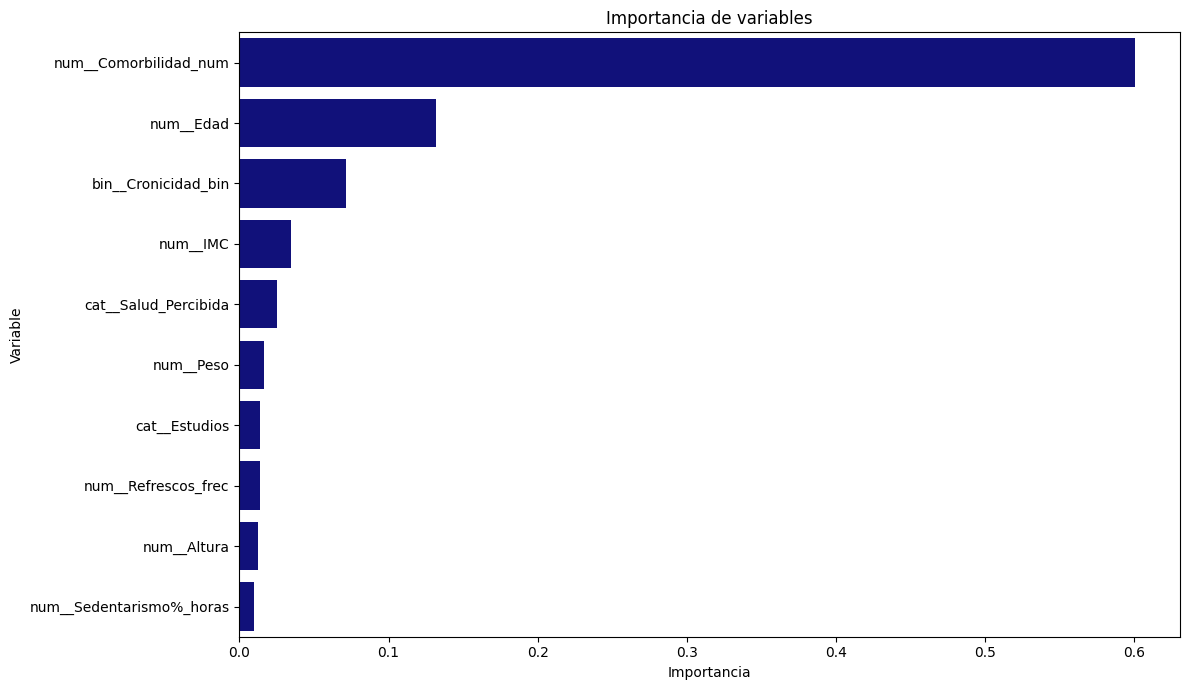

In [ ]:
plt.figure(figsize=(12, 7))
plt.title("Importancia de variables")
sns.barplot(x=importancias.values, y=importancias.index, color='darkblue')
plt.xlabel('Importancia')
plt.ylabel('Variable')
plt.tight_layout()
plt.show()

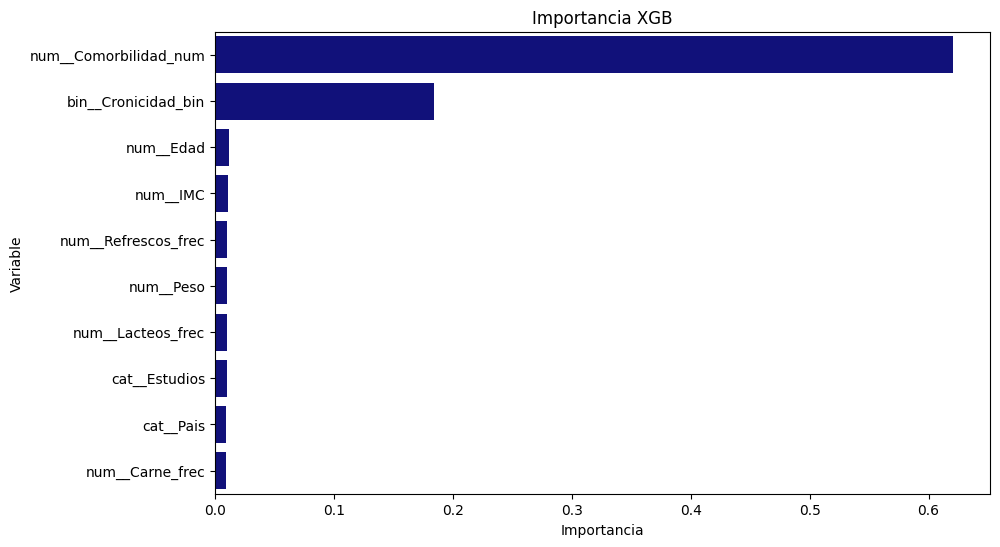

In [ ]:
# Metodo tomado de https://scikit-learn.org/stable/auto_examples/ensemble/plot_forest_importances.html#data-generation-and-model-fitting

imp_var_xgb= pipe_xgb.named_steps["modelo"].feature_importances_
var_nom_xgb= preprocesado.get_feature_names_out()

importancia_xgb= pd.Series(imp_var_xgb, index=var_nom_xgb)
importancia_xgb= importancia_xgb.sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=importancia_xgb.values, y=importancia_xgb.index, color='darkblue')
plt.title('Importancia XGB')
plt.xlabel('Importancia')
plt.ylabel('Variable')
plt.show()

In [ ]:
print(importancia_xgb)

num__Comorbilidad_num    0.620757
bin__Cronicidad_bin      0.184158
num__Edad                0.011820
num__IMC                 0.010495
num__Refrescos_frec      0.010113
num__Peso                0.009926
num__Lacteos_frec        0.009911
cat__Estudios            0.009759
cat__Pais                0.009541
num__Carne_frec          0.009501
dtype: float32


# Entrenamiento con las variables escogidas para Streamlite

Las variables en ambas listas son:

1. num__Comorbilidad_num
2. bin__Cronicidad_bin
3. num__Edad
4. num__IMC
5. num__Refrescos_frec
6. num__Peso
7. cat__Estudios

De estas 7, la 1 y la dos son datos de salud sensibles, por lo que se usaran: Edad, Peso y Altura para tener un correcto IMC, La frecuencia de consumo de refrescos, el nivel de estudio y el sedentarismo, que esta incluido dentro de las variables mas importantes del Random Forest.

In [ ]:
df_streamlite= df_final.copy()

In [ ]:
var_stream= ['Edad', 'IMC', 'Estudios','Refrescos_frec', 'Sedentarismo%_horas','Hipertension_bin','Peso', 'Altura' ]
df_streamlite= df_streamlite[var_stream]

In [ ]:
df_streamlite= df_streamlite.dropna(subset=['Hipertension_bin'])

# Hipertensión

In [ ]:
objetivo= 'Hipertension_bin'
df_cat= df_streamlite.select_dtypes(include='object')
df_num= df_streamlite.select_dtypes(include=np.number).drop(columns=['Diabetes_bin','Colesterol_bin', 'Hipertension_bin','Cronicidad_bin'], errors='ignore')
print("\nColumnas categoricas:", df_cat.columns.to_list())
print("\nColumnas numericas:", df_num.columns.to_list())



Columnas categoricas: ['Estudios']

Columnas numericas: ['Edad', 'IMC', 'Refrescos_frec', 'Sedentarismo%_horas', 'Peso', 'Altura']


In [ ]:
X= df_streamlite.drop(columns=['Hipertension_bin'])
y =df_streamlite[objetivo]
X_train, X_test, y_train, y_test= train_test_split(X,y,test_size=0.25,random_state=42,stratify=y)



In [ ]:
num_transformer= Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),('scaler', StandardScaler())])
cat_transformer= Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),('Ordinal', OrdinalEncoder())])


preprocesado= ColumnTransformer([('num', num_transformer, df_num.columns.to_list()),('cat', cat_transformer, df_cat.columns.to_list())])


In [ ]:
pipelines= {"Regresion Logistica": Pipeline([("preprocesado", preprocesado), ("modelo", LogisticRegression(max_iter=2000, random_state=42))]),
            "Random Forest": Pipeline([("preprocesado", preprocesado), ("modelo", RandomForestClassifier(random_state=42,n_estimators=600,n_jobs=-1))]),
            "Gradient Boosting": Pipeline([("preprocesado", preprocesado), ("modelo", GradientBoostingClassifier(learning_rate=0.05, random_state=42, n_estimators=600))])}

modelos= list(pipelines.values())

In [ ]:
resultados= {}
nom_modelos= ['Regresion Logistica', 'Random Forest', 'Gradient Boosting']

for nombre, pipeln in pipelines.items():
  print(f"Modelo: {nombre}")
  pipeln.fit(X_train, y_train)
  pred= pipeln.predict(X_test)

  acc= accuracy_score(y_test, pred)
  f1= f1_score(y_test, pred, average='macro', zero_division=0) # Manejo de undefined metric warning
  resultados[nombre]= f1
  print(f"Accuracy: {acc:.2f}")
  print(f"F1: {f1:.2f}")

  print(classification_report(y_test, pred, zero_division=0))
  print(confusion_matrix(y_test, pred))

Modelo: Regresion Logistica
Accuracy: 0.76
F1: 0.68
              precision    recall  f1-score   support

         0.0       0.79      0.89      0.84      3668
         1.0       0.63      0.44      0.52      1513

    accuracy                           0.76      5181
   macro avg       0.71      0.67      0.68      5181
weighted avg       0.74      0.76      0.75      5181

[[3269  399]
 [ 847  666]]
Modelo: Random Forest
Accuracy: 0.75
F1: 0.68
              precision    recall  f1-score   support

         0.0       0.80      0.88      0.83      3668
         1.0       0.60      0.45      0.52      1513

    accuracy                           0.75      5181
   macro avg       0.70      0.66      0.68      5181
weighted avg       0.74      0.75      0.74      5181

[[3222  446]
 [ 830  683]]
Modelo: Gradient Boosting
Accuracy: 0.76
F1: 0.69
              precision    recall  f1-score   support

         0.0       0.80      0.87      0.84      3668
         1.0       0.61      0.48  

In [ ]:
# Se verifica si se obtienen mejores resultados con otros modelos

pipe_xgb= Pipeline([("preprocesado", preprocesado), ("modelo", XGBClassifier(objective="binary:logistic", n_estimators=600, learning_rate=0.05, max_depth=5, random_state=42))])

pipe_xgb.fit(X_train, y_train)
pred_xgb= pipe_xgb.predict(X_test)

acc_xgb= accuracy_score(y_test, pred_xgb)
f1_xgb= f1_score(y_test, pred_xgb, average='macro')
print(f"Accuracy: {acc_xgb:.2f}")
print(f"F1: {f1_xgb:.2f}")
print(classification_report(y_test, pred_xgb))
print(confusion_matrix(y_test, pred_xgb))

Accuracy: 0.75
F1: 0.68
              precision    recall  f1-score   support

         0.0       0.80      0.87      0.83      3668
         1.0       0.60      0.46      0.52      1513

    accuracy                           0.75      5181
   macro avg       0.70      0.67      0.68      5181
weighted avg       0.74      0.75      0.74      5181

[[3204  464]
 [ 811  702]]


In [ ]:
# lightGBM

from lightgbm import LGBMClassifier

pipe_lgbm= Pipeline([("preprocesado", preprocesado), ("modelo", LGBMClassifier(n_estimators=600, learning_rate=0.05, max_depth=-1, random_state=42))])

pipe_lgbm.fit(X_train, y_train)
pred_lgbm= pipe_lgbm.predict(X_test)

acc_lgbm= accuracy_score(y_test, pred_lgbm)
f1_lgbm= f1_score(y_test, pred_lgbm, average='macro')
print(f"Accuracy: {acc_lgbm:.2f}")
print(f"F1: {f1_lgbm:.2f}")
print(classification_report(y_test, pred_lgbm))
print(confusion_matrix(y_test, pred_lgbm))

[LightGBM] [Info] Number of positive: 4540, number of negative: 11003
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001385 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 539
[LightGBM] [Info] Number of data points in the train set: 15543, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.292093 -> initscore=-0.885241
[LightGBM] [Info] Start training from score -0.885241
Accuracy: 0.75
F1: 0.68
              precision    recall  f1-score   support

         0.0       0.80      0.87      0.83      3668
         1.0       0.60      0.47      0.53      1513

    accuracy                           0.75      5181
   macro avg       0.70      0.67      0.68      5181
weighted avg       0.74      0.75      0.74      5181

[[3198  470]
 [ 807  706]]


In [ ]:
joblib.dump(preprocesado, "preprocesador_slt.joblib")
hipertension= (pipelines["Regresion Logistica"])
joblib.dump(hipertension, "hipertension.joblib")


['hipertension.joblib']

In [ ]:
df_streamlite.to_csv("df_streamlite.csv", index=False, encoding='latin1')
files.download("df_streamlite.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Diabetes

In [ ]:
var_stream2= ['Edad', 'IMC', 'Estudios','Refrescos_frec', 'Sedentarismo%_horas','Diabetes_bin','Peso', 'Altura' ]

In [ ]:
df_streamlite2= df_final.copy()

In [ ]:
df_streamlite2= df_streamlite2[var_stream2]

In [ ]:
df_streamlite2= df_streamlite2.dropna(subset=['Diabetes_bin'])

In [ ]:
objetivo= 'Diabetes_bin'
df_cat= df_streamlite.select_dtypes(include='object')
df_num= df_streamlite.select_dtypes(include=np.number).drop(columns=['Diabetes_bin','Colesterol_bin', 'Hipertension_bin','Cronicidad_bin'], errors='ignore')
print("\nColumnas categoricas:", df_cat.columns.to_list())
print("\nColumnas numericas:", df_num.columns.to_list())



Columnas categoricas: ['Estudios']

Columnas numericas: ['Edad', 'IMC', 'Refrescos_frec', 'Sedentarismo%_horas', 'Peso', 'Altura']


In [ ]:
X= df_streamlite2.drop(columns=['Diabetes_bin'])
y =df_streamlite2[objetivo]
X_train, X_test, y_train, y_test= train_test_split(X,y,test_size=0.25,random_state=42,stratify=y)



In [ ]:
num_transformer= Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),('scaler', StandardScaler())])
cat_transformer= Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),('Ordinal', OrdinalEncoder())])


preprocesado= ColumnTransformer([('num', num_transformer, df_num.columns.to_list()),('cat', cat_transformer, df_cat.columns.to_list())])


In [ ]:
print(preprocesado.transformers)

[('num', Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())]), ['Edad', 'IMC', 'Refrescos_frec', 'Sedentarismo%_horas', 'Peso', 'Altura']), ('cat', Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('Ordinal', OrdinalEncoder())]), ['Estudios'])]


In [ ]:
pipelines= {"Regresion Logistica": Pipeline([("preprocesado", preprocesado), ("modelo", LogisticRegression(max_iter=2000, random_state=42))]),
            "Random Forest": Pipeline([("preprocesado", preprocesado), ("modelo", RandomForestClassifier(random_state=42,n_estimators=600,class_weight="balanced",n_jobs=-1))]),
            "Gradient Boosting": Pipeline([("preprocesado", preprocesado), ("modelo", GradientBoostingClassifier(learning_rate=0.05, random_state=42, n_estimators=600))])}

modelos= list(pipelines.values())

In [ ]:
resultados= {}
nom_modelos= ['Regresion Logistica', 'Random Forest', 'Gradient Boosting']

for nombre, pipeln in pipelines.items():
  print(f"Modelo: {nombre}")
  pipeln.fit(X_train, y_train)
  pred= pipeln.predict(X_test)

  acc= accuracy_score(y_test, pred)
  f1= f1_score(y_test, pred, average='macro', zero_division=0) # Manejo de undefined metric warning
  resultados[nombre]= f1
  print(f"Accuracy: {acc:.2f}")
  print(f"F1: {f1:.2f}")

  print(classification_report(y_test, pred, zero_division=0))
  print(confusion_matrix(y_test, pred))

Modelo: Regresion Logistica
Accuracy: 0.90
F1: 0.49
              precision    recall  f1-score   support

         0.0       0.90      1.00      0.95      4714
         1.0       0.48      0.02      0.04       504

    accuracy                           0.90      5218
   macro avg       0.69      0.51      0.49      5218
weighted avg       0.86      0.90      0.86      5218

[[4703   11]
 [ 494   10]]
Modelo: Random Forest
Accuracy: 0.90
F1: 0.51
              precision    recall  f1-score   support

         0.0       0.91      0.99      0.94      4714
         1.0       0.26      0.04      0.07       504

    accuracy                           0.90      5218
   macro avg       0.58      0.51      0.51      5218
weighted avg       0.84      0.90      0.86      5218

[[4653   61]
 [ 483   21]]
Modelo: Gradient Boosting
Accuracy: 0.90
F1: 0.50
              precision    recall  f1-score   support

         0.0       0.91      0.99      0.95      4714
         1.0       0.34      0.03  

In [ ]:
X_train.columns

Index(['Edad', 'IMC', 'Estudios', 'Refrescos_frec', 'Sedentarismo%_horas',
       'Peso', 'Altura'],
      dtype='object')

In [ ]:
# Se verifica si se obtienen mejores resultados con otros modelos

pipe_xgb= Pipeline([("preprocesado", preprocesado), ("modelo", XGBClassifier(objective="binary:logistic", n_estimators=600, learning_rate=0.05, max_depth=5, random_state=42))])

pipe_xgb.fit(X_train, y_train)
pred_xgb= pipe_xgb.predict(X_test)

acc_xgb= accuracy_score(y_test, pred_xgb)
f1_xgb= f1_score(y_test, pred_xgb, average='macro')
print(f"Accuracy: {acc_xgb:.2f}")
print(f"F1: {f1_xgb:.2f}")
print(classification_report(y_test, pred_xgb))
print(confusion_matrix(y_test, pred_xgb))

Accuracy: 0.90
F1: 0.50
              precision    recall  f1-score   support

         0.0       0.91      0.99      0.95      4714
         1.0       0.27      0.03      0.06       504

    accuracy                           0.90      5218
   macro avg       0.59      0.51      0.50      5218
weighted avg       0.84      0.90      0.86      5218

[[4671   43]
 [ 488   16]]


In [ ]:
joblib.dump(pipe_xgb, "diabetes.joblib")

['diabetes.joblib']

# Colesterol

In [ ]:
var_stream3= ['Edad', 'IMC', 'Estudios','Refrescos_frec', 'Sedentarismo%_horas','Colesterol_bin','Peso', 'Altura' ]

In [ ]:
df_streamlite3= df_final.copy()

In [ ]:
df_streamlite3= df_streamlite3[var_stream3]

In [ ]:
df_streamlite3= df_streamlite3.dropna(subset=['Colesterol_bin'])

In [ ]:
objetivo= 'Colesterol_bin'
df_cat= df_streamlite.select_dtypes(include='object')
df_num= df_streamlite.select_dtypes(include=np.number).drop(columns=['Diabetes_bin','Colesterol_bin', 'Hipertension_bin','Cronicidad_bin'], errors='ignore')
print("\nColumnas categoricas:", df_cat.columns.to_list())
print("\nColumnas numericas:", df_num.columns.to_list())



Columnas categoricas: ['Estudios']

Columnas numericas: ['Edad', 'IMC', 'Refrescos_frec', 'Sedentarismo%_horas', 'Peso', 'Altura']


In [ ]:
X= df_streamlite3.drop(columns=['Colesterol_bin'])
y =df_streamlite3[objetivo]
X_train, X_test, y_train, y_test= train_test_split(X,y,test_size=0.25,random_state=42,stratify=y)



In [ ]:
num_transformer= Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),('scaler', StandardScaler())])
cat_transformer= Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),('Ordinal', OrdinalEncoder())])


preprocesado= ColumnTransformer([('num', num_transformer, df_num.columns.to_list()),('cat', cat_transformer, df_cat.columns.to_list())])


In [ ]:
pipelines= {"Regresion Logistica": Pipeline([("preprocesado", preprocesado), ("modelo", LogisticRegression(max_iter=2000, random_state=42))]),
            "Random Forest": Pipeline([("preprocesado", preprocesado), ("modelo", RandomForestClassifier(random_state=42,n_estimators=600,class_weight="balanced",n_jobs=-1))]),
            "Gradient Boosting": Pipeline([("preprocesado", preprocesado), ("modelo", GradientBoostingClassifier(learning_rate=0.05, random_state=42, n_estimators=600))])}

modelos= list(pipelines.values())

In [ ]:
resultados= {}
nom_modelos= ['Regresion Logistica', 'Random Forest', 'Gradient Boosting']

for nombre, pipeln in pipelines.items():
  print(f"Modelo: {nombre}")
  pipeln.fit(X_train, y_train)
  pred= pipeln.predict(X_test)

  acc= accuracy_score(y_test, pred)
  f1= f1_score(y_test, pred, average='macro', zero_division=0) # Manejo de undefined metric warning
  resultados[nombre]= f1
  print(f"Accuracy: {acc:.2f}")
  print(f"F1: {f1:.2f}")

  print(classification_report(y_test, pred, zero_division=0))
  print(confusion_matrix(y_test, pred))

Modelo: Regresion Logistica
Accuracy: 0.73
F1: 0.54
              precision    recall  f1-score   support

         0.0       0.76      0.93      0.83      3837
         1.0       0.45      0.16      0.24      1360

    accuracy                           0.73      5197
   macro avg       0.60      0.55      0.54      5197
weighted avg       0.68      0.73      0.68      5197

[[3563  274]
 [1136  224]]
Modelo: Random Forest
Accuracy: 0.73
F1: 0.57
              precision    recall  f1-score   support

         0.0       0.77      0.92      0.83      3837
         1.0       0.48      0.22      0.30      1360

    accuracy                           0.73      5197
   macro avg       0.62      0.57      0.57      5197
weighted avg       0.69      0.73      0.69      5197

[[3513  324]
 [1065  295]]
Modelo: Gradient Boosting
Accuracy: 0.74
F1: 0.54
              precision    recall  f1-score   support

         0.0       0.76      0.95      0.84      3837
         1.0       0.50      0.15  

In [ ]:
# Se verifica si se obtienen mejores resultados con otros modelos

pipe_xgb= Pipeline([("preprocesado", preprocesado), ("modelo", XGBClassifier(objective="binary:logistic", n_estimators=600, learning_rate=0.05, max_depth=5, random_state=42))])

pipe_xgb.fit(X_train, y_train)
pred_xgb= pipe_xgb.predict(X_test)

acc_xgb= accuracy_score(y_test, pred_xgb)
f1_xgb= f1_score(y_test, pred_xgb, average='macro')
print(f"Accuracy: {acc_xgb:.2f}")
print(f"F1: {f1_xgb:.2f}")
print(classification_report(y_test, pred_xgb))
print(confusion_matrix(y_test, pred_xgb))

Accuracy: 0.74
F1: 0.56
              precision    recall  f1-score   support

         0.0       0.76      0.93      0.84      3837
         1.0       0.49      0.19      0.27      1360

    accuracy                           0.74      5197
   macro avg       0.63      0.56      0.56      5197
weighted avg       0.69      0.74      0.69      5197

[[3572  265]
 [1103  257]]


In [ ]:
joblib.dump(pipe_xgb, "colesterol.joblib")

['colesterol.joblib']

In [ ]:
print(preprocesado.transformers)

[('num', Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())]), ['Edad', 'IMC', 'Refrescos_frec', 'Sedentarismo%_horas', 'Peso', 'Altura']), ('cat', Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('Ordinal', OrdinalEncoder())]), ['Estudios'])]


In [ ]:
X_train.columns

Index(['Edad', 'IMC', 'Estudios', 'Refrescos_frec', 'Sedentarismo%_horas',
       'Peso', 'Altura'],
      dtype='object')

In [ ]:
df_streamlite['Sedentarismo%_horas'].unique()

array([ 9., 15.,  8.,  6., 10., 11.,  2.,  0.,  3., nan,  7.,  4.,  1.,
        5., 14., 12., 13., 16., 23., 22., 20., 18., 21., 17., 19.])

In [ ]:
df_entrada= pd.DataFrame([{'Edad':50, 'IMC':19, 'Estudios':'Enseñanzas profesionales de grado medio o equivalentes',
                           'Refrescos_frec': 1.5, 'Sedentarismo%_horas': 8, 'Peso': 70, 'Altura': 170}])


cat_pred= pipe_xgb.predict(df_entrada)[0]
cat_prob= pipe_xgb.predict_proba(df_entrada)[0].max()

noms= {0: "Genial, no tienes riesgo",1: "Cuidado, hay riesgo"}
cat_prediccion= noms[int(cat_pred)]


print(f"{cat_prediccion}, con una probaliidad de: {cat_prob*100:.2f}%")

print("Prediccion para:")
print(tabulate(df_entrada, headers='keys', tablefmt='psql'))

Genial, no tienes riesgo, con una probaliidad de: 84.33%
Prediccion para:
+----+--------+-------+--------------------------------------------------------+------------------+-----------------------+--------+----------+
|    |   Edad |   IMC | Estudios                                               |   Refrescos_frec |   Sedentarismo%_horas |   Peso |   Altura |
|----+--------+-------+--------------------------------------------------------+------------------+-----------------------+--------+----------|
|  0 |     50 |    19 | Enseñanzas profesionales de grado medio o equivalentes |              1.5 |                     8 |     70 |      170 |
+----+--------+-------+--------------------------------------------------------+------------------+-----------------------+--------+----------+


In [ ]:
df_final['Comunidad Autonoma'].unique()

array(['País Vasco', 'Castilla - La Mancha', 'Comunitat Valenciana',
       'Andalucía', 'Castilla y León', 'Extremadura', 'Balears, Illes',
       'Cataluña', 'Galicia', 'Aragón', 'Rioja, La',
       'Madrid, Comunidad de', 'Murcia, Región de',
       'Navarra, Comunidad Foral de', 'Asturias, Principado de',
       'Canarias', 'Cantabria', 'Ceuta', 'Melilla'], dtype=object)

In [ ]:
## Geson data  https://github.com/codeforgermany/click_that_hood/blob/main/public/data/spain-communities.geojson?short_path=01a35b9